# (21) conv latents:  reproduce linear case

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>

This means:
- ```K = 512```
- ```M = 1```

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['track_stats'] = True

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-8_b-4_k-512_m-1_<ngd|lin>
b200-ep300-lr(0.001)_temp(0.05)_gr(200)_(2025_06_21,21:37)

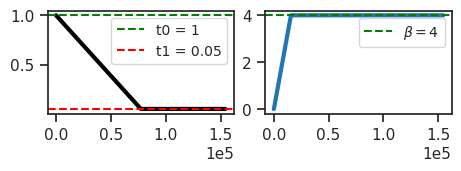

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50], device='cuda:0', dtype=torch.int32)

In [7]:
tr.train('ConvPhi:ReproduceLinear')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 300, avg loss: 118.795: 100%|███████| 300/300 [1:01:21<00:00, 12.27s/it]


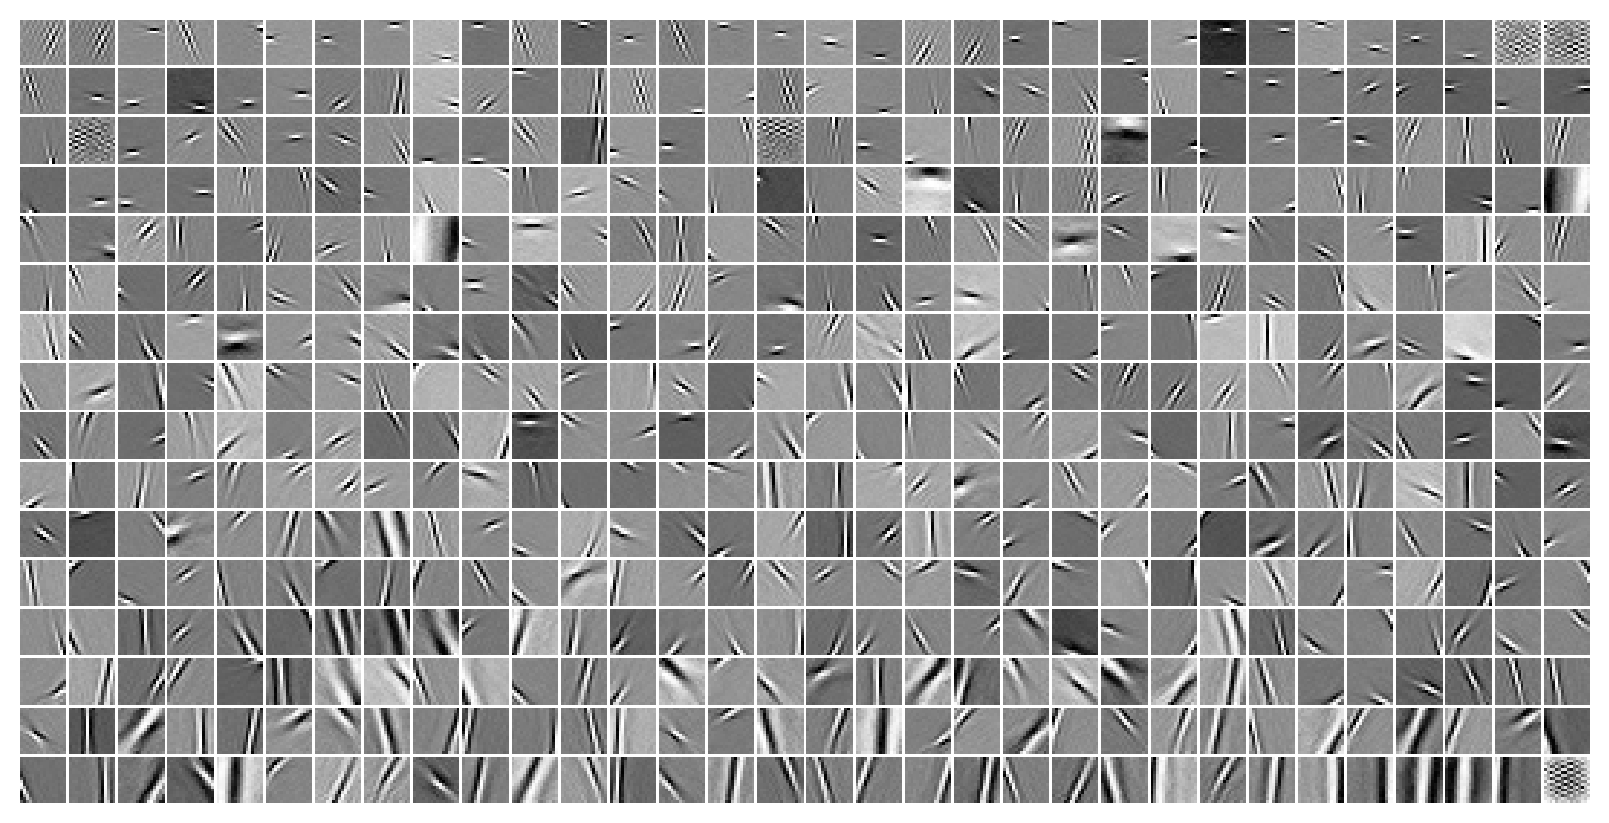

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████| 130/130 [04:36<00:00,  2.13s/it]


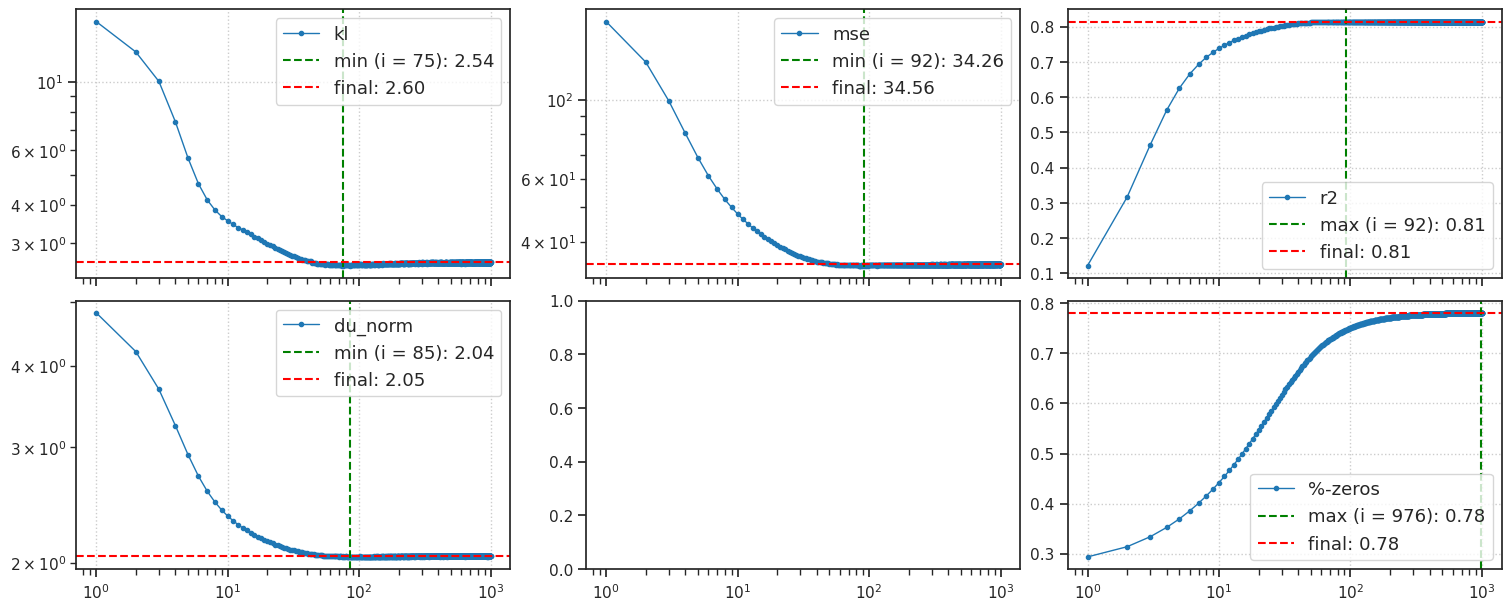

CPU times: user 5min 39s, sys: 13.6 s, total: 5min 53s
Wall time: 5min 53s


In [15]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=-1,
    compute_sprs=False,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

100%|███████████████████████████████████| 5/5 [00:10<00:00,  2.07s/it]


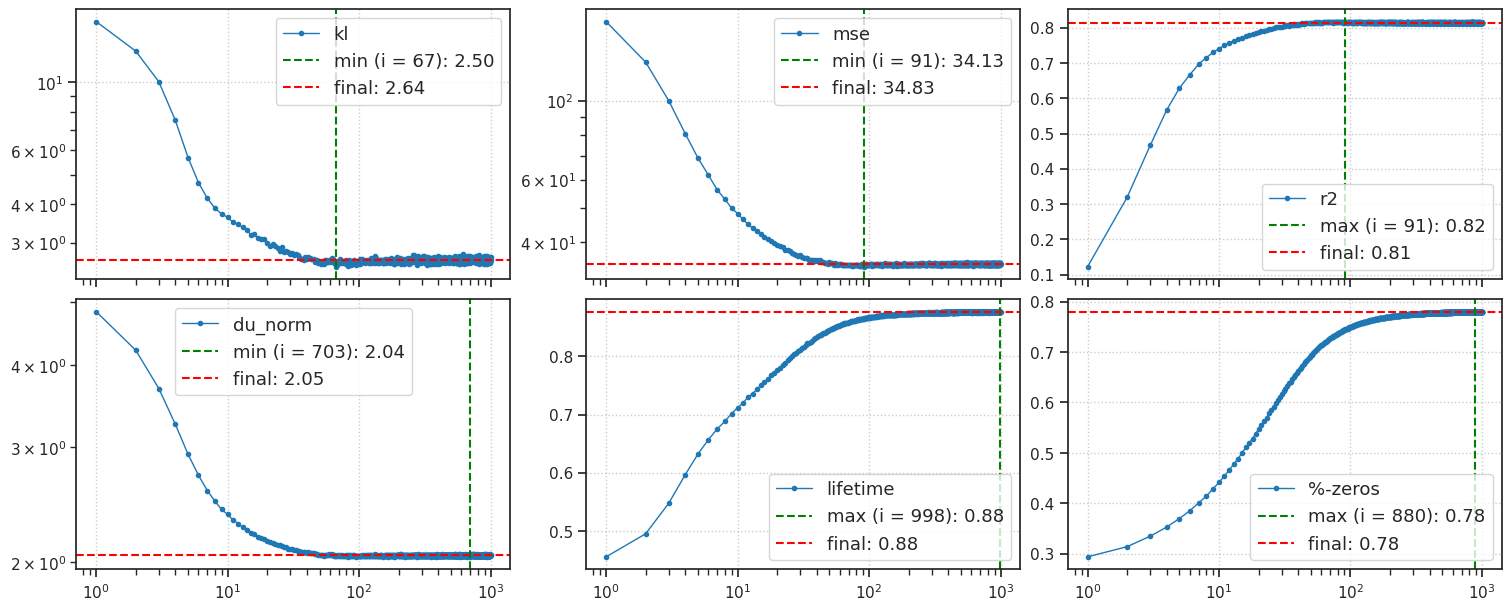

CPU times: user 14.5 s, sys: 476 ms, total: 15 s
Wall time: 15.3 s


In [16]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=True,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

In [10]:
# a = 'poisson_vH16-wht_t-8_b-4_k-512_m-1_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:ReproduceLinear_(2025_06_21,21:01)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']